## Contextualizacion con proteomica para un mutante y datos de crecimiento y uptakes

In [1]:
# Cargamos las librerias necesarias para esta seccion si no lanzamos todo
import cobra
import pandas as pd
from reframed.cobra.transcriptomics import gene_to_reaction_expression
from reframed import from_cobrapy
import numpy as np


### Creamos los modelos

In [2]:
# Los mutantes son de proteinas no asociadas directamente al metabolismo con lo que
# no se crean KOs ya que el modelo no tiene la proteina. Vamos a contextualizar el modelo con la expresion y luego a hacer los KOs de las fuentes de carbono y nitrogeno para ver su efecto en el crecimiento

WT=cobra.io.load_model("STM_v1_0")



Set parameter Username
Set parameter LicenseID to value 2789756
Academic license - for non-commercial use only - expires 2027-03-10


### Cargamos las funciones para el GIMME simpliicado

In [3]:
# Vamos a adaptar los datos de proteomica a la contextualizacion de los modelos con GIMME, necesitamos un diccionario con el id del gen en el modelo como clave y la abundancia de la proteina como valor. Vamos a hacer esto para cada una de las condiciones (lppA early, lppA late, lppB early, lppB late, WT early, WT late)
# transformamos los datos de proteomica a un formato compatible con la contextualizacion de los modelos con GIMME, 
# necesitamos un diccionario con el id del gen en el modelo como clave y la abundancia de la proteina como valor. 
# Vamos a hacer esto para cada una de las condiciones (ΔlppA early, ΔlppA late, ΔlppB early, ΔlppB late, WT early, WT late)
def proteomics_to_gimme_dict(proteomics_df,id_column="STM_ID", expression_columns=["ΔlppA early","ΔlppA late","ΔlppB early","ΔlppB late","WT early","WT late"]): 
    # Funcion para trasformar los datos de proteomica, dando el id de la columna con la expresion y la del id del gen, devuelve un diccionario con el id de la condicion 
    # y como valor otro diccionario que tiene como ids los ids del gen y de valor la abundancia de la proteina
    proteomics_dict={}
    for condition in expression_columns:
        proteomics_dict[condition]={}
        
    for index, row in proteomics_df.iterrows():
        gene_id=row[id_column]
        for condition in expression_columns:
            proteomics_dict[condition][gene_id]=row[condition]
    return(proteomics_dict)
# Exp2 transformation of numeric arrays
def transform_log_exp(expression_df):
    transformed=expression_df.copy()
    for (columnName, columnData) in expression_df.items():
        print('Column Name : ', columnName)
        if columnName != 'ProbeID':
            exp_values=np.exp2(columnData.values)
            expression_df[columnName]=exp_values
    return(expression_df)


    
# Create a COBRA model from GIMME function with simplifications. Only reactions with a threadshold expression are included and the reactions required to grow as well.
def create_simplified_GIMME_model(model,expression,cutoff=0.25):
    model_gimme=model.copy()
    rf_model = from_cobrapy(model)
    dict_out={}
    reaction_values=gene_to_reaction_expression(rf_model, expression)
    #Calculamos la expression minima para asumir funcionalidad
    # Pasamos de dict a numpy array
    expression_values= reaction_values.values()
    expression_values_list = list(expression_values) 
    expression_values_numpy = np.array(expression_values_list)
    threadshold=np.quantile(expression_values_numpy,cutoff)
    #Calculamos reacciones esenciales para no tenerlas en cuenta
    try:
        essential_reactions=cobra.flux_analysis.find_essential_reactions(model_gimme)
    except:
        essential_reactions=[]
        
    essential_reactions_ids=[reaction.id for reaction in essential_reactions]
    #Calculamos las reacciones que pasan del corte por expression
    for key,value in reaction_values.items():
        if value > threadshold:
            dict_out[key]=value
        else:
            if key not in essential_reactions_ids:
                old_bounds=model_gimme.reactions.get_by_id(key).bounds
                model_gimme.reactions.get_by_id(key).knock_out()
                if model_gimme.slim_optimize()==0:
                    model_gimme.reactions.get_by_id(key).bounds=old_bounds
                    dict_out[key]="Reinserted"
                else:
                    dict_out[key]="KO"
            else:
                dict_out[key]="Essential"
    # Deshabilitamos las reacciones que no han pasado el corte de expression
    for reaction,expression in reaction_values.items():
        if reaction not in dict_out:
            model_gimme.reactions.get_by_id(reaction).knock_out()
    return(dict_out,model_gimme)



# Función para suprimir la salida
def suppress_output(func):
    def wrapper(*args, **kwargs):
        # Redirigir la salida estándar a un objeto StringIO
        original_stdout = sys.stdout
        sys.stdout = io.StringIO()
        try:
            return func(*args, **kwargs)
        finally:
            # Restaurar la salida estándar
            sys.stdout = original_stdout
    return wrapper

# Decorar la función de copia del modelo para suprimir la salida
@suppress_output
def copy_model(model):
    return model.copy()



def get_carbon_sources_GIMME(model, expression_data, carbon_uptake=-10,normalize=True,original_source='EX_glc__D_e',carbon_source_list=[],save_memory=False,cutoff=0.25):
    if save_memory:
        cobra.io.write_sbml_model(model,"tmp.xml")
    output_df=pd.DataFrame(columns=["Reaction","N_carbons","Metabolite","Name","Growth"])
    output_reactions_df=pd.DataFrame()
    if len(carbon_source_list)==0:
        reaction_list=model.reactions
    else:
        reaction_list=carbon_source_list

    for reaction in reaction_list:
        my_id=reaction.id
        if reaction.boundary and not reaction.id.startswith("DM_"):
            for exchange_metabolite in reaction.metabolites: # Deberia haber solo un metabolito
                if 'C' in exchange_metabolite.elements.keys():
                    n_carbons=exchange_metabolite.elements['C']
                    name=exchange_metabolite.name
                    if save_memory:
                        model_tmp=cobra.io.read_sbml_model("tmp.xml")
                    else:
                        model_tmp=copy_model(model)  
                    #model_tmp.reactions.get_by_id(original_source).lower_bound=0 # Se modifica el uptake de la fuente original
                    model_tmp.reactions.get_by_id(original_source).knock_out()
                    if normalize:
                        model_tmp.reactions.get_by_id(my_id).lower_bound=carbon_uptake/n_carbons
                    else:
                        model_tmp.reactions.get_by_id(my_id).lower_bound=carbon_uptake

                    # create GIMME model with the carbon source selected
                    GIMME_reactions,model_GIMME_tmp=create_simplified_GIMME_model(model_tmp,expression_data,cutoff)
                    # Get the growth of the new model
                    try:
                        sol=model_GIMME_tmp.slim_optimize()
                    except:
                        sol=0
                    # Combination with the new results
                    output_df=pd.concat([output_df, pd.DataFrame([[reaction.id,n_carbons,exchange_metabolite,name,sol]],columns=["Reaction","N_carbons","Metabolite","Name","Growth"])], ignore_index=True)
                    if output_reactions_df.empty:
                        output_reactions_df=pd.DataFrame.from_dict(GIMME_reactions, orient='index')
                        output_reactions_df=output_reactions_df.rename(columns={"value": exchange_metabolite.id})
                    else:
                        output_reactions_df = pd.concat([output_reactions_df, pd.DataFrame.from_dict(GIMME_reactions, orient='index')], axis=1, join="inner")
                        output_reactions_df=output_reactions_df.rename(columns={"value": exchange_metabolite.id})
    return(output_reactions_df,output_df)

def get_nitrogen_sources_GIMME(model, expression_data, nitrogen_uptake=-10,normalize=True,original_source='EX_nh4_e',nitrogen_source_list=[],save_memory=False,cutoff=0.25):
    if save_memory:
        cobra.io.write_sbml_model(model,"tmp.xml")
    output_df=pd.DataFrame(columns=["Reaction","N_nitrogens","Metabolite","Name","Growth"])
    output_reactions_df=pd.DataFrame()
    if len(nitrogen_source_list)==0:
        reaction_list=model.exchanges
    else:
        reaction_list=nitrogen_source_list

    for reaction in reaction_list:
        my_id=reaction.id
        if reaction.boundary and not reaction.id.startswith("DM_"):
            for exchange_metabolite in reaction.metabolites: # Deberia haber solo un metabolito
                if 'N' in exchange_metabolite.elements.keys():
                    n_nitrogens=exchange_metabolite.elements['N']
                    name=exchange_metabolite.name
                    if save_memory:
                        model_tmp=cobra.io.read_sbml_model("tmp.xml")
                    else:
                        model_tmp=copy_model(model)  
                    model_tmp.reactions.get_by_id(original_source).lower_bound=0 # Se modifica el uptake de la fuente original
                    #model_tmp.reactions.get_by_id(original_source).knock_out()
                    if normalize:
                        model_tmp.reactions.get_by_id(my_id).lower_bound=nitrogen_uptake/n_nitrogens
                    else:
                        model_tmp.reactions.get_by_id(my_id).lower_bound=nitrogen_uptake

                    # create GIMME model with the carbon source selected
                    GIMME_reactions,model_GIMME_tmp=create_simplified_GIMME_model(model_tmp,expression_data,cutoff)
                    # Get the growth of the new model
                    try:
                        sol=model_GIMME_tmp.slim_optimize()
                    except:
                        sol=0
                    # Combination with the new results
                    output_df=pd.concat([output_df, pd.DataFrame([[reaction.id,n_nitrogens,exchange_metabolite,name,sol]],columns=["Reaction","N_nitrogens","Metabolite","Name","Growth"])], ignore_index=True)
                    if output_reactions_df.empty:
                        output_reactions_df=pd.DataFrame.from_dict(GIMME_reactions, orient='index')
                        output_reactions_df=output_reactions_df.rename(columns={"value": exchange_metabolite.id})
                    else:
                        output_reactions_df = pd.concat([output_reactions_df, pd.DataFrame.from_dict(GIMME_reactions, orient='index')], axis=1, join="inner")
                        output_reactions_df=output_reactions_df.rename(columns={"value": exchange_metabolite.id})
    return(output_reactions_df,output_df)


    
#  Combina tablas de flujos de gimme en una sola tabla
def create_flux_table(model,expression_lists,names):
    rf_model = from_cobrapy(model)
    solution_df = pd.DataFrame()
    for idx,expression in enumerate(expression_lists):
        solution_gimme=GIMME(rf_model, expression, 25, 0.9, constraints=None, parsimonious=False)
        if solution_df.empty:
            solution_df=solution_gimme.to_dataframe()
            solution_df=solution_df.rename(columns={"value": names[idx]})
        else:
            solution_df = pd.concat([solution_df, solution_gimme.to_dataframe()], axis=1, join="inner")
            solution_df=solution_df.rename(columns={"value": names[idx]})
    return(solution_df)

### Leemos la proteomica y la adaptamos a la expresion

In [4]:
# Vammos a leer datos de proteomica para ver si se pueden contextualizar los modelos y ver si el efecto de las KOs es mas evidente
# El formato de la tabla tiene una columna STM_ID con el id del gen en el modelo, 
# Excel formato:
# STM_ID: id del gen en el modelo
# lppA early: abundancia de la proteina lppA en la fase temprana
# lppA late: abundancia de la proteina lppA en la fase tardia
# lppB early: abundancia de la proteina lppB en la fase temprana
# lppB late: abundancia de la proteina lppB en la fase tardia
# WT early: abundancia de la proteina en el WT en la fase temprana
# WT late: abundancia de la proteina en el WT en la fase tardia
import pandas as pd
proteomics_data=pd.read_excel(r"/home/yannis/CNB/Salmonella/PROTEOMICA-LppA-LppB-Salmonella_v2.xlsx")

In [5]:
# Con los datos de proteomica vamos a comparar la expresion entre:
# - WT early contra ΔlppA early
# - WT early contra ΔlppB early
# - WT late contra ΔlppA late
# - WT late contra ΔlppB late
# - ΔlppA early contra ΔlppB early
# - ΔlppA late contra ΔlppB late
# Calculando log2FC de cada comparativa y añadiendo una nueva columna a la tabla de proteomica con el resultado de cada comparativa
def log2_fold_change(sample1, sample2):
    return np.log2(sample1 / sample2)
comparisons=[("WT early","ΔlppA early"),("WT early","ΔlppB early"),("WT late","ΔlppA late"),("WT late","ΔlppB late"),("ΔlppA early","ΔlppB early"),("ΔlppA late","ΔlppB late")]
for comparison in comparisons:
    proteomics_data[comparison[0]+" vs "+comparison[1]]=log2_fold_change(proteomics_data[comparison[0]],proteomics_data[comparison[1]])




In [6]:
# Salvamos la proteomica para analizarlo con bioconductor
proteomics_data.to_csv("/home/yannis/CNB/Salmonella/proteomics_data_transformed.csv",index=False,sep='\t')

## creacion de los modelos contextualizados

In [7]:
# Vamos a contextualizar el modelo WT con los datos de proteomica
proteomics_dict=proteomics_to_gimme_dict(proteomics_data)
proteomics_dict

{'ΔlppA early': {'PSLT046': 329714.17578125,
  'STM0002': 9404713.5,
  'STM0003': 2631184.0625,
  'STM0004': 7080350.0,
  'STM0005': 374866.09375,
  'STM0007': 9708596.375,
  'STM0008': 242762.578125,
  'STM0012': 5452368.125,
  'STM0013': 1092872.90625,
  'STM0028': 47189.091796875,
  'STM0029': 4743.16485595703,
  'STM0032': 5111.64178466797,
  'STM0039': 103614.80859375,
  'STM0040': 38447.791015625,
  'STM0041': 119540.75,
  'STM0043': 1299966.0625,
  'STM0045': 316951.1953125,
  'STM0046': 847971.71875,
  'STM0048': 173588.1484375,
  'STM0049': 180598.9765625,
  'STM0051': 531500.3828125,
  'STM0052': 24698.7041015625,
  'STM0055': 27938.5815429687,
  'STM0064': 1546848.0625,
  'STM0066': 2058799.5625,
  'STM0067': 1354621.03125,
  'STM0070': 124891.88671875,
  'STM0080': 27079.3891601562,
  'STM0081': 155958.15234375,
  'STM0082': 602254.328125,
  'STM0085': 159473.6015625,
  'STM0086': 64865.443359375,
  'STM0087': 352200.890625,
  'STM0088': 245989.58984375,
  'STM0089': 353143

In [8]:
# Forzar gurobi como solver
WT.solver = "gurobi"

# Cutoffs específicos por cada condicion
cutoffs = {
    "ΔlppA early": 0.135,
    "ΔlppA late": 0.2,
    "ΔlppB early": 0.158,
    "ΔlppB late": 0.185,
    "WT early": 0.195,
    "WT late": 0.2
}

# Por cada condicion hacemos un modelo contextualizado
salmonella_models={}
salmonella_reactions={}
for condition, expression in proteomics_dict.items():
    GIMME_reactions,model_GIMME_tmp=create_simplified_GIMME_model(WT,expression,cutoff=cutoffs[condition])
    salmonella_models[condition]=model_GIMME_tmp
    salmonella_reactions[condition]=GIMME_reactions


Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmpkw7p1iu0.lp
Reading time = 0.03 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmpi1qg5f_v.lp
Reading time = 0.02 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmppn37zprp.lp
Reading time = 0.02 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmpcjzhxfs9.lp
Reading time = 0.03 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmp68gs1o6d.lp
Reading time = 0.05 seconds
: 1802 rows, 5090 columns, 19612 nonzeros
Read LP format model from file C:\Users\yanni\AppData\Local\Temp\tmpz5vk9c6h.lp
Reading time = 0.02 seconds
: 1802 rows, 5090 columns, 19612 nonzeros


In [9]:
# Salvamos los modelos contextualizados para cada condicion y en un excel las reacciones que se han mantenido, eliminado o reinsertado en cada modelo contextualizado
salmonella_reactions_df=pd.DataFrame()
for condition, reactions in salmonella_reactions.items():
    reactions_df=pd.DataFrame.from_dict(reactions, orient='index', columns=[condition])
    if salmonella_reactions_df.empty:
        salmonella_reactions_df=reactions_df
    else:
        salmonella_reactions_df = pd.concat([salmonella_reactions_df, reactions_df], axis=1, join="outer")
salmonella_reactions_df.to_excel("salmonella_reactions_cutoffespecificos.xlsx")
for condition, model in salmonella_models.items():
    cobra.io.save_json_model(model, f"{condition}_model_cutoff_{cutoffs[condition]}.json")

    import os
print(os.getcwd())


\\wsl.localhost\Ubuntu\home\yannis\CNB\CNB\Scripts\Python


In [10]:
# En caso de ya haber salvado los modelos y las reacciones, se pueden cargar directamente sin necesidad de volver a hacer todo el proceso de contextualizacion
# Cargar modelos contextualizados
# chequeamos si salmonella_models esta definido o qe no esta vacio para evitar volver a cargar los modelos si ya estan cargados en memoria

if 'salmonella_models' not in globals() or not salmonella_models:
    salmonella_models={}
    for condition in proteomics_dict.keys():
        model=cobra.io.load_json_model(f"{condition}_model_cutoff_{cutoffs[condition]}.json")
        salmonella_models[condition]=model

In [11]:
# Plotear para cada modelo el production envelope mostrando el crecimiento respecto al consumo de o2
def plot_production_envelope(model, growth_reaction_id="BIOMASS_iRR1083_metals", oxygen_exchange_id="EX_o2_e", condition_name="Condition"):
    import matplotlib.pyplot as plt
    import numpy as np
    from cobra.flux_analysis import production_envelope
    # Calculamos el production envelope para la reaccion de crecimiento y el intercambio de oxigeno
    try:
        envelope = production_envelope(model, reactions=[oxygen_exchange_id], objective=growth_reaction_id, points=20)
        # Ploteamos el production envelope
        plt.figure(figsize=(8, 6))
        plt.plot(envelope[oxygen_exchange_id], envelope['flux_maximum'], marker='o')
        plt.title(f'Production Envelope for {condition_name}')
        plt.xlabel('Oxygen Exchange Flux (mmol/gDW/h)')
        plt.ylabel('Growth Rate (1/h)')
        plt.grid()
        plt.show()
    except Exception as e:
        print(f"Error calculating production envelope for {condition_name}: {e}")


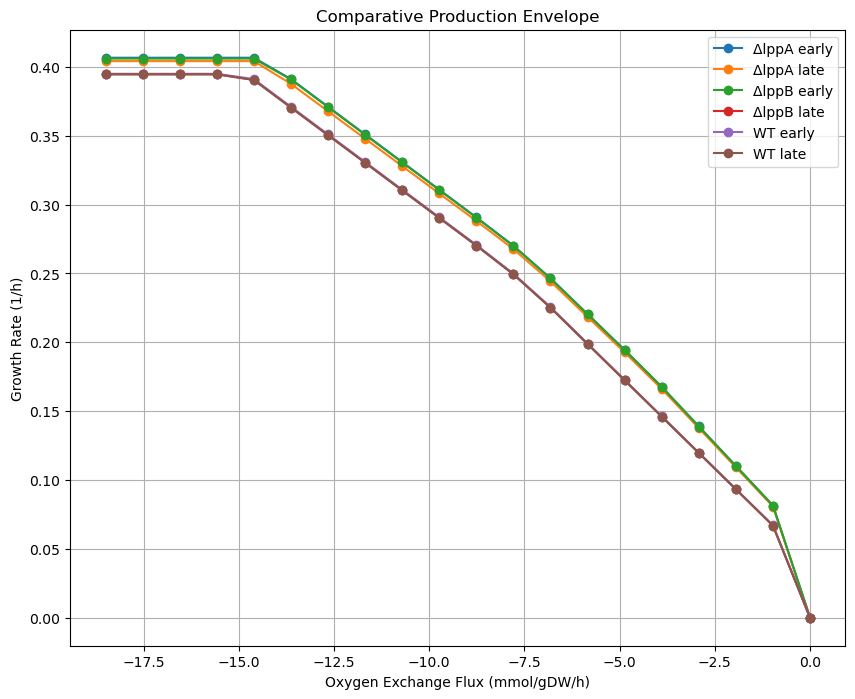

In [12]:
# funcion para plotear el production envelope de todos los modelos contextualizados en el mismo plot para comparar entre condiciones
def plot_comparative_production_envelope(models_dict, growth_reaction_id="BIOMASS_iRR1083_metals", oxygen_exchange_id="EX_o2_e"):
    import matplotlib.pyplot as plt
    import numpy as np
    from cobra.flux_analysis import production_envelope
    plt.figure(figsize=(10, 8))
    for condition_name, model in models_dict.items():
        try:
            envelope = production_envelope(model, reactions=[oxygen_exchange_id], objective=growth_reaction_id, points=20)
            plt.plot(envelope[oxygen_exchange_id], envelope['flux_maximum'], marker='o', label=condition_name)
        except Exception as e:
            print(f"Error calculating production envelope for {condition_name}: {e}")
    plt.title('Comparative Production Envelope')
    plt.xlabel('Oxygen Exchange Flux (mmol/gDW/h)')
    plt.ylabel('Growth Rate (1/h)')
    plt.grid()
    plt.legend()
    plt.show()
plot_comparative_production_envelope(salmonella_models, growth_reaction_id="BIOMASS_iRR1083_metals", oxygen_exchange_id="EX_o2_e")

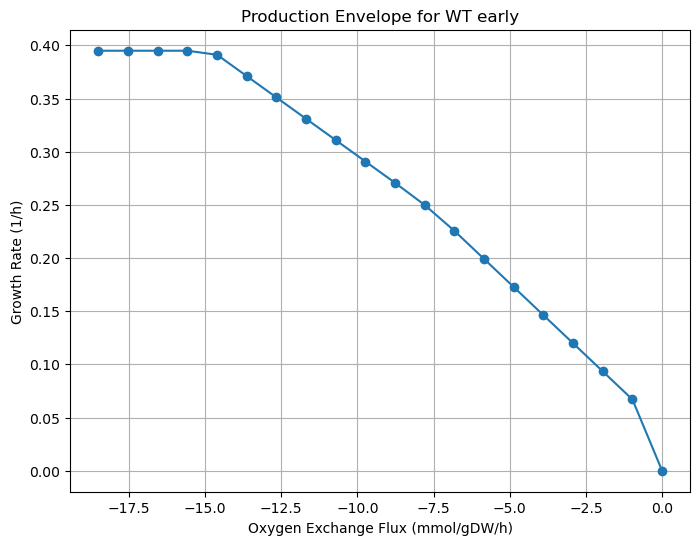

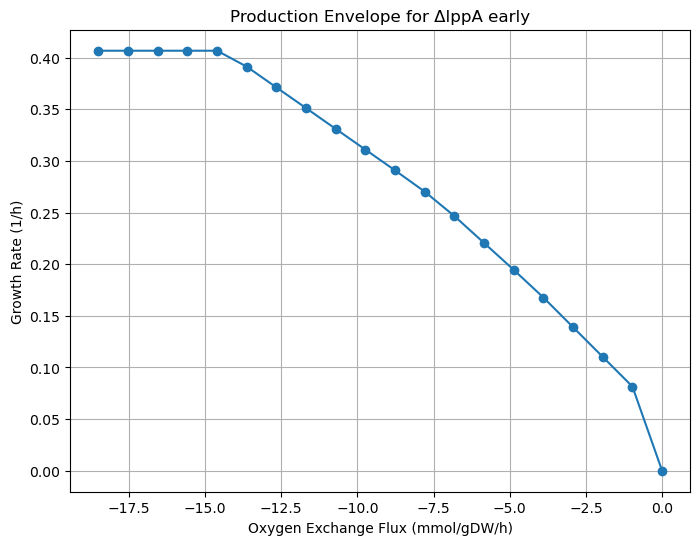

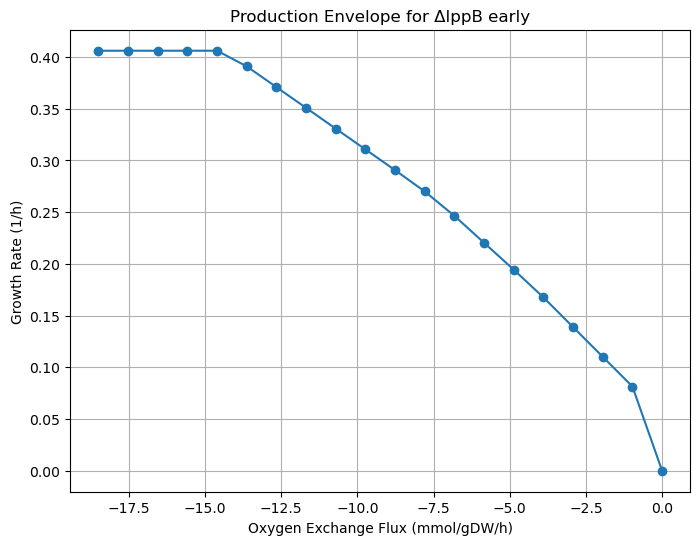

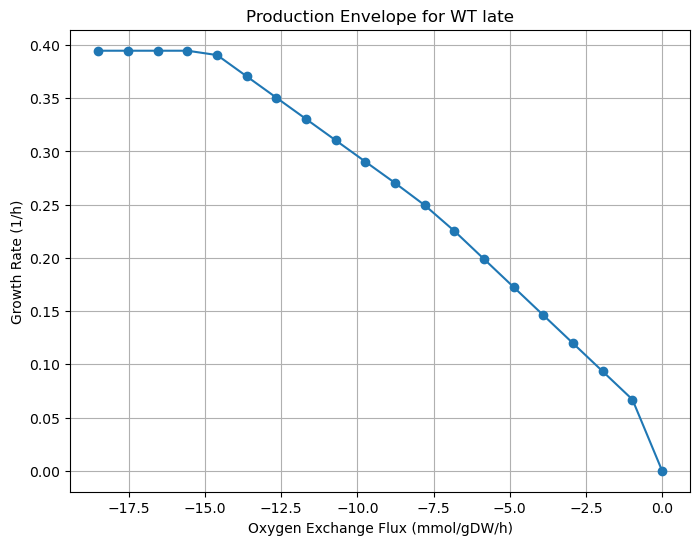

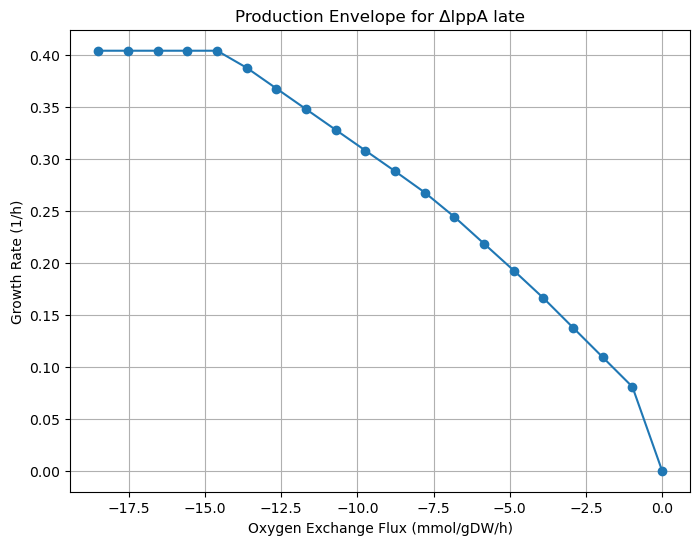

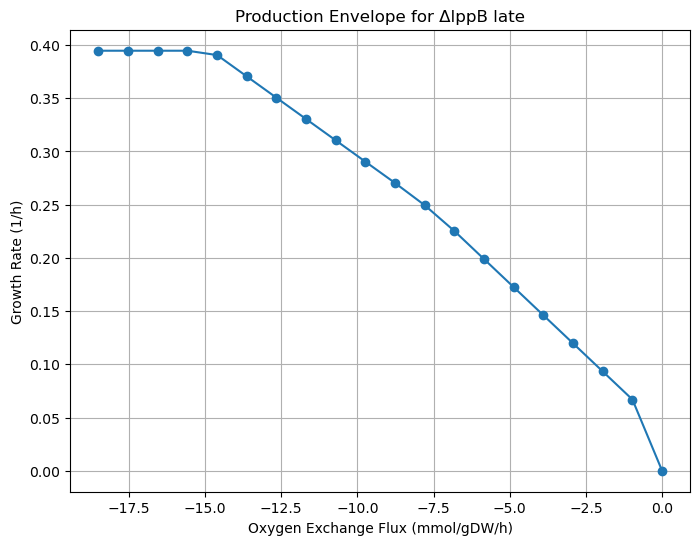

In [13]:
plot_production_envelope(salmonella_models["WT early"], condition_name="WT early")
plot_production_envelope(salmonella_models["ΔlppA early"], condition_name="ΔlppA early")
plot_production_envelope(salmonella_models["ΔlppB early"], condition_name="ΔlppB early")
plot_production_envelope(salmonella_models["WT late"], condition_name="WT late")
plot_production_envelope(salmonella_models["ΔlppA late"], condition_name="ΔlppA late")
plot_production_envelope(salmonella_models["ΔlppB late"], condition_name="ΔlppB late")

In [14]:
import ast

class NumericEvaluator(ast.NodeVisitor):

    def visit_Constant(self, node):
        return node.value

    def visit_BoolOp(self, node):
        values = [self.visit(v) for v in node.values]

        if isinstance(node.op, ast.And):
            result = values[0]
            for v in values[1:]:
                result = min(result, v)
            return result

        elif isinstance(node.op, ast.Or):
            result = values[0]
            for v in values[1:]:
                result = result + v
            return result

    def visit_Expression(self, node):
        return self.visit(node.body)


def evaluate_expression(expr):
    tree = ast.parse(expr, mode='eval')
    evaluator = NumericEvaluator()
    return evaluator.visit(tree)


# Reimplementamos la funcion gene_to_reaction_expression para que devuelva un diccionario con los ids de las reacciones como claves y como valor otro diccionario con las condiciones del diccionario de expresion como claves y el valor de expresion de la reaccion en cada condicion como valor. 
# Esto nos permitira tener un formato mas facil de manejar para comparar la expresion de las reacciones entre condiciones.
def get_reaction_expression(model, gene_expression_dict):
    reaction_expression_dict={}
    # Evaluamos si el diccionario de expresion tiene una o varias condiciones, si tiene una sola condicion, la convertimos a un formato con una sola columna para facilitar el procesamiento
    if len(gene_expression_dict.keys())==1:
        single_condition=list(gene_expression_dict.keys())[0]
        gene_expression_dict={single_condition: gene_expression_dict[single_condition]}
    else:        
        gene_expression_dict=gene_expression_dict
    # Iteramos sobre cada reaccion del modelo
    for reaction in model.reactions:
        # Obtenemos la regla GPR de la reaccion
        gpr = reaction.gene_reaction_rule
        if gpr == "":
            # Si la reaccion no tiene una regla GPR, asignamos un valor de expresion de 0 para todas las condiciones
            reaction_expression_dict[reaction.id]={condition: 0 for condition in gene_expression_dict.keys()}
        else:
            # Si la reaccion tiene una regla GPR, calculamos su expresion a partir de la expresion de los genes que la codifican
            reaction_expression_dict[reaction.id]={}
            for condition in gene_expression_dict.keys():
                # Reemplazamos los ids de los genes en la regla GPR por sus valores de expresion correspondientes a la condicion actual
                gpr_condition = gpr
                for gene in reaction.genes:
                    gene_id = gene.id
                    if gene_id in gene_expression_dict[condition]:
                        # Hacemos el log de la expresion del gen para que los valores de expresion sean mas comparables entre genes, ya que la expresion de los genes puede variar mucho entre ellos, y el log nos permite reducir esa variabilidad y hacer que los valores sean mas comparables. Ademas, el log nos permite manejar mejor los valores de expresion cercanos a 0, ya que el log de un valor cercano a 0 es un valor negativo grande, lo que nos permite diferenciar mejor entre genes con expresion baja.
                        gene_expression_value = np.log1p(gene_expression_dict[condition][gene_id])
                    else:
                        gene_expression_value = 0
                    gpr_condition = gpr_condition.replace(gene_id, str(gene_expression_value))

                # Evaluamos la regla GPR para obtener el valor de expresion de la reaccion en la condicion actual
                try:
                    reaction_expression_value = evaluate_expression(gpr_condition)
                except Exception as e:
                    print(f"Error evaluating GPR for reaction {reaction.id} in condition {condition},gpr: {gpr_condition}: {e}")
                    reaction_expression_value = 0
                reaction_expression_dict[reaction.id][condition] = reaction_expression_value
    return reaction_expression_dict


# Vamos a desarrollar una funcion que calcule la expresion de las reacciones a partir de la expresion de los genes.
# Dado un modelo de cobra y un diccionario con la expresion de los genes, que puede tener una o varias condiciones, devuelve un dataframe con la expresion de las reacciones para cada condicion. La expresion de una reaccion se calcula a partir de la expresion de los genes que la codifican, aplicando las reglas de gene-protein-reaccion (GPR) del modelo. Si una reaccion tiene una regla GPR con un "AND" entre dos genes, la expresion de la reaccion sera el minimo entre la expresion de los dos genes. Si una reaccion tiene una regla GPR con un "OR" entre dos genes, la expresion de la reaccion sera el maximo entre la expresion de los dos genes. Si una reaccion no tiene una regla GPR, se le asigna un valor de expresion de 0. El dataframe resultante tendra como indice los ids de las reacciones y como columnas las condiciones del diccionario de expresion.
def gene_to_reaction_expression(model, gene_expression_dict):
    # Evaluamos si el diccionario de expresion tiene una o varias condiciones, si tiene una sola condicion, la convertimos a un formato con una sola columna para facilitar el procesamiento
    if len(gene_expression_dict.keys())==1:
        single_condition=list(gene_expression_dict.keys())[0]
        gene_expression_dict={single_condition: gene_expression_dict[single_condition]}
    else:        
        gene_expression_dict=gene_expression_dict
    
    reaction_expression_df=get_reaction_expression(model, gene_expression_dict)
    reaction_expression_df=pd.DataFrame.from_dict(reaction_expression_df, orient='index')
    return reaction_expression_df  

In [15]:
reaction_expression_df=gene_to_reaction_expression(WT, proteomics_dict)
# Hacemos un heatmap de la expresion de las reacciones para cada condicion mostrando solo las reacciones que tienen expresion mayor a 0 en al menos una condicion
import seaborn as sns
import matplotlib.pyplot as plt
# Filtramos las reacciones que tienen expresion mayor a 0 en al menos una condicion
filtered_reactions = reaction_expression_df[(reaction_expression_df > 0).any(axis=1)]


In [16]:
# Filtramos las reacciones que tiene una sd entre las condiciones mayor a 0.5 para mostrar solo las reacciones que tienen una variabilidad de expresion entre condiciones significativa, ya que las reacciones que tienen una expresion similar en todas las condiciones no nos aportan informacion sobre las diferencias entre condiciones.
reaction_expression_df["sd"]=reaction_expression_df.std(axis=1)
filtered_reactions = reaction_expression_df[reaction_expression_df["sd"] > 0.5].drop(columns=["sd"])
# Para reducir el numero de reacciones, agrupar las que tienen los mismos perfiles de expresion entre condiciones.
#  Sus IDs que son el indice del dataframe, pasaran a ser concatenacion de los IDs de las reacciones agrupadas, separados por un guion. 
# Esto nos permitira reducir el numero de filas del heatmap y facilitar la visualizacion de las diferencias entre condiciones.

# Para ello vamos a buscar las filas que tienen el mismo perfil de expresion entre condiciones, es decir, las filas que tienen los mismos valores en todas las columnas de condiciones. A todas las que esten asociadas al mismo perfil darles un valor nmerico que seria su valor de la columna grupo
# Agrupar y construir nuevo dataframe
df_sin_duplicados = (
    filtered_reactions.groupby(filtered_reactions.columns.tolist(), as_index=False)
      .apply(lambda g: g.iloc[[0]].assign(
          new_index="-".join(g.index.astype(str))
      ))
      .reset_index(drop=True)
      .set_index("new_index")
)

#Normalizar los valores por reaccion para mostrar colores escalados para cada reaccion, es decir, que el color de cada reaccion se escale entre el valor minimo y maximo de expresion de esa reaccion en todas las condiciones, para facilitar la comparacion entre condiciones para cada reaccion
filtered_reactions_normalized = df_sin_duplicados.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)


C:\Users\yanni\AppData\Local\Temp\ipykernel_18664\463208673.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.iloc[[0]].assign(


Text(0.5, 2954.4444444444443, 'Condition')

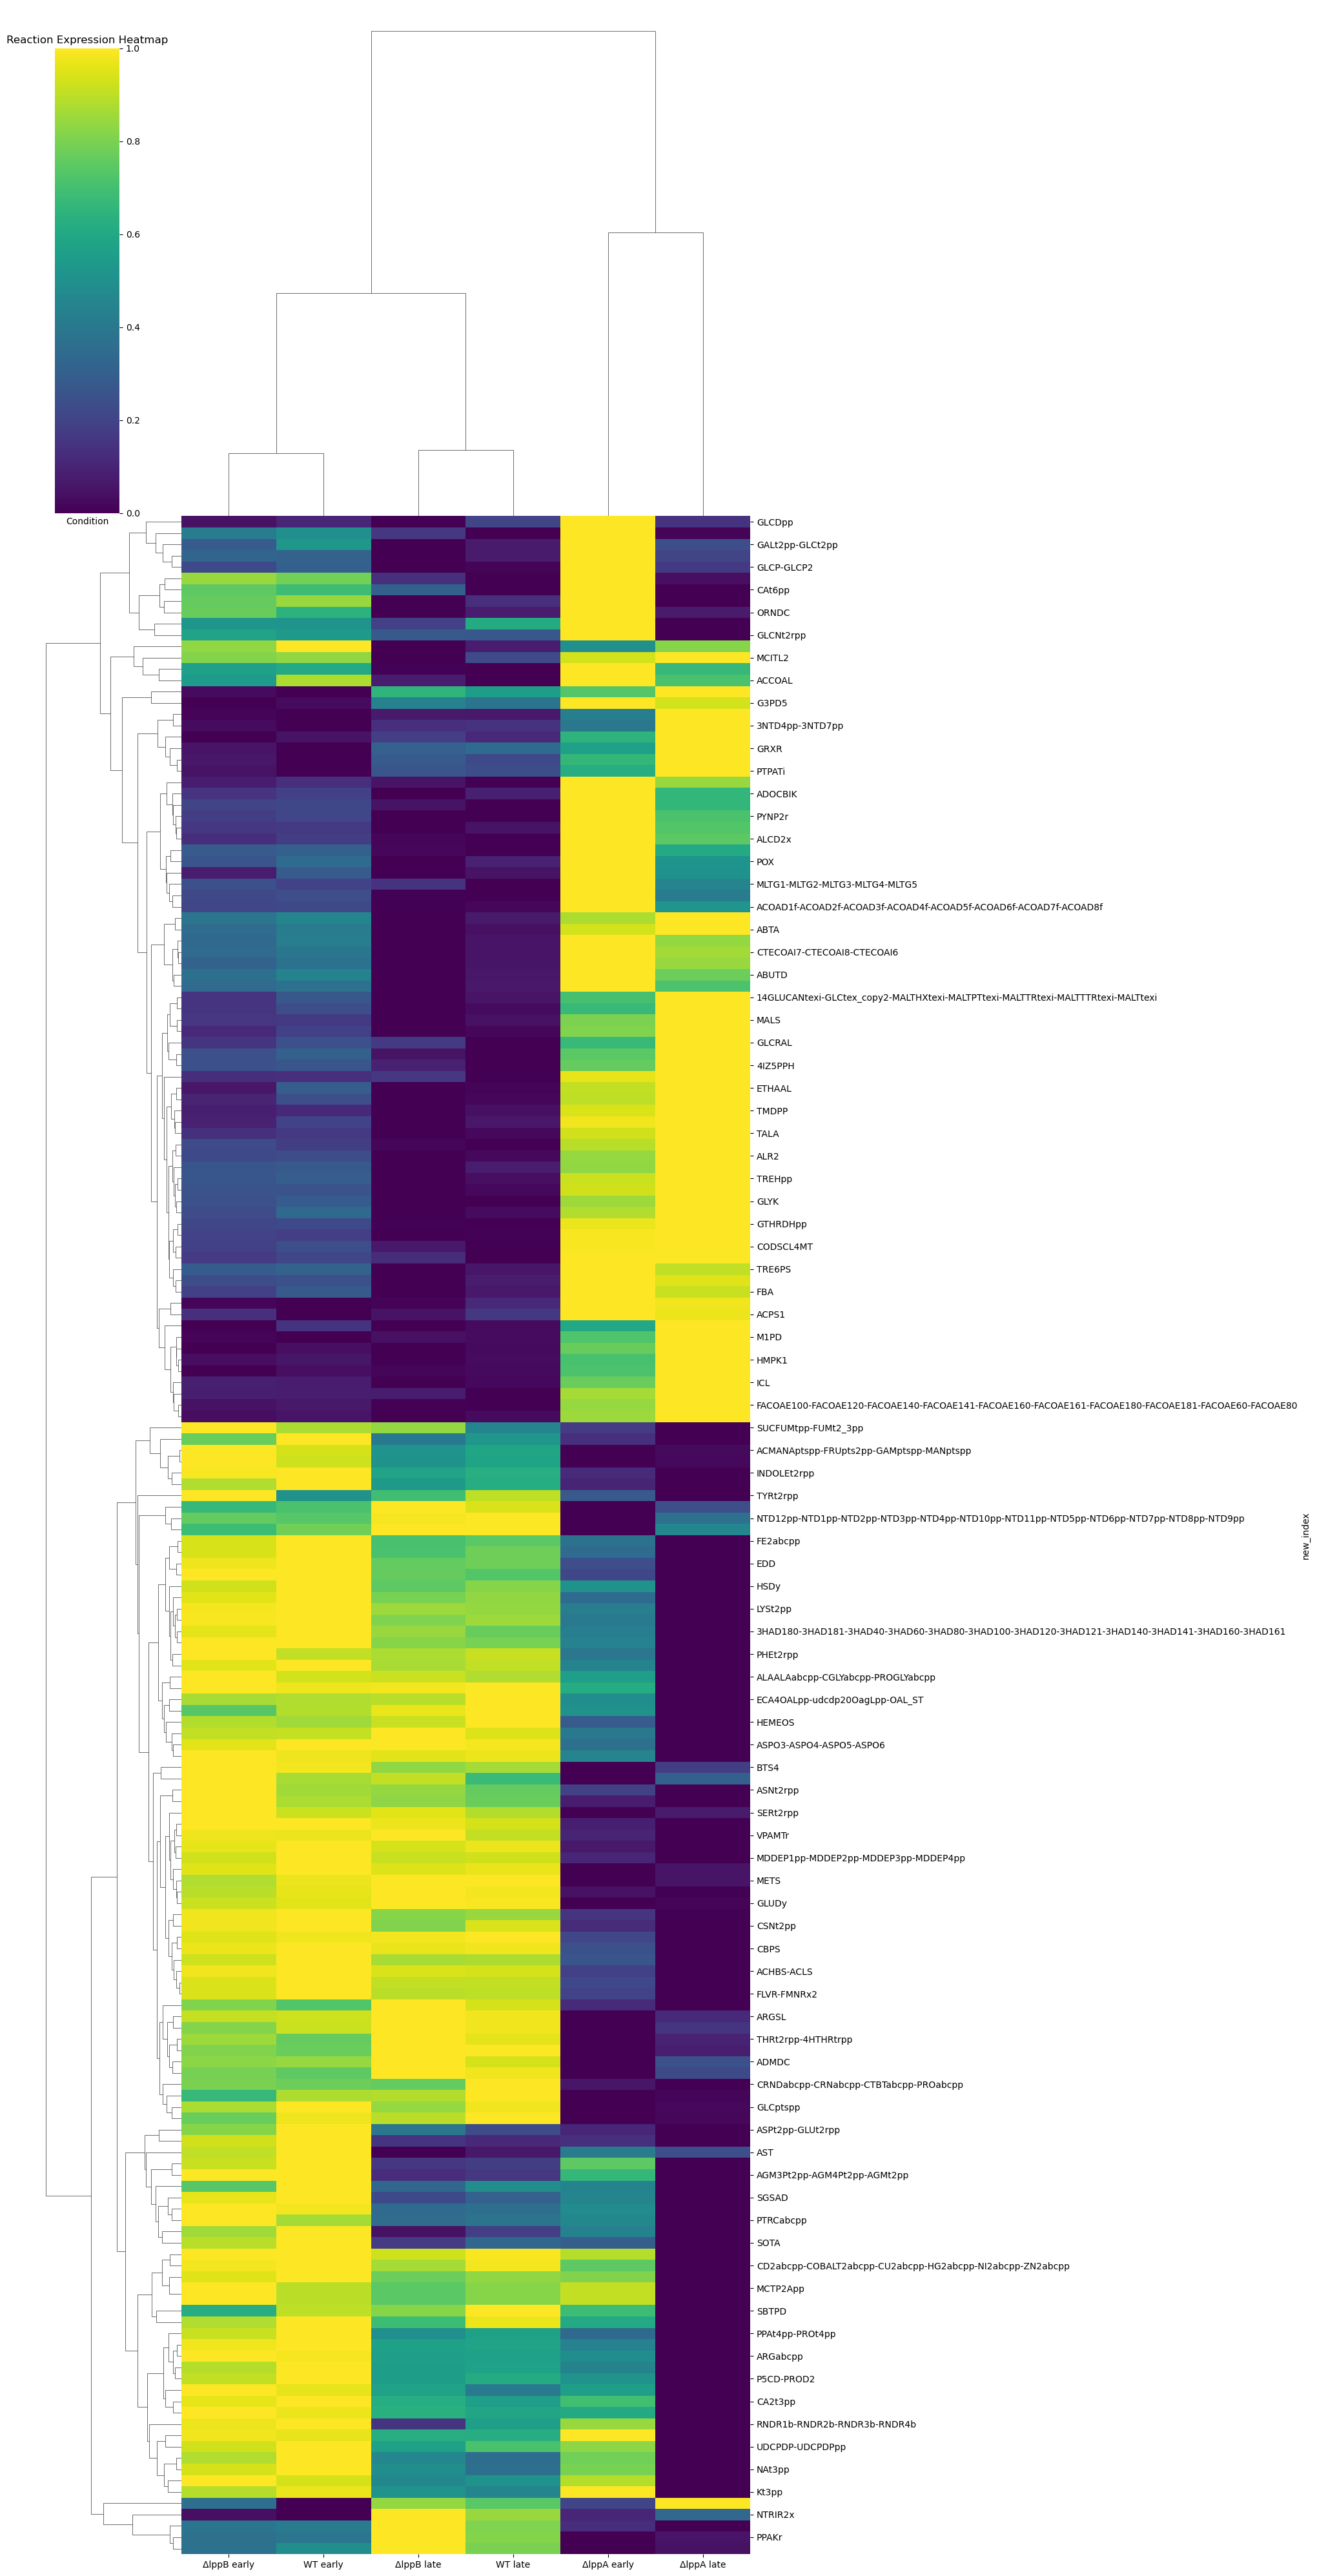

In [17]:
# Mostrar colores escalados para cada reaccion, es decir, que el color de cada reaccion se escale entre el valor minimo y maximo de expresion de esa reaccion en todas las condiciones, para facilitar la comparacion entre condiciones para cada reaccion
sns.clustermap(filtered_reactions_normalized   , cmap="viridis",figsize=(20, 40))
plt.title("Reaction Expression Heatmap")
plt.xlabel("Condition")

In [18]:
# Ahora vamos a hacer lo mismo pero con subsistemas, leyendo el subsistema de cada reaccion a partir del csv asociado
# Leemos los datos de mapeo entre reacciones  subsistemas de iBb1018
subsystem_mapping_df = pd.read_csv(r"/home/yannis/CNB/Salmonella/subsystems_iJN1480.csv",sep="\t")
# el nombre de la columna con los ids de las reacciones es "Abbreviation" y el nombre de la columna con los nombres de los subsistemas es "Subsystem"
# los subsistemas hay que limpiarlos qitando +AF- S+AF8- o +AF8Xw-
subsystem_mapping_df["Subsystem"] = subsystem_mapping_df["Subsystem"].str.replace(r"S\+AF-|\+AF8-|\+AF8AXw-", " ", regex=True)

subsystem_mapping = subsystem_mapping_df.set_index("Abbreviation")["Subsystem"].to_dict()

def get_expression_by_subsystem(reaction_expression_df, subsystem_mapping):
    reaction_expression_log_df = reaction_expression_df.map(lambda x: np.log2(x + 1))
    # Añadimos una nueva columna al dataframe de expresion de reacciones con el subsistema de cada reaccion, utilizando el diccionario de mapeo entre reacciones y subsistemas
    reaction_expression_log_df["Subsystem"] = reaction_expression_log_df.index.map(subsystem_mapping)
    # Agrupamos el dataframe por subsistema y calculamos la media de expresion de las reacciones que pertenecen a cada subsistema para cada condicion, devolviendo un nuevo dataframe con el subsistema como indice y las condiciones como columnas.
    # log transform the protein expression values to make them more comparable between subsystems, since the expression of the reactions can vary a lot between them, and the log allows us to reduce that variability and make the values more comparable. In addition, the log allows us to better handle expression values close to 0, since the log of a value close to 0 is a large negative value, which allows us to better differentiate between subsystems with low expression.

    subsystem_expression_df = reaction_expression_log_df.groupby("Subsystem").mean()
    return subsystem_expression_df

# Funcion para leer el diccionario de las expresiones por condicion y transformarlo en un datarame con las expresiones de las reacciones por subsistema para cada condicion, utilizando el diccionario de mapeo entre reacciones y subsistemas
def get_subsystem_expression_by_condition(reaction_expression_df, subsystem_mapping):
    subsystem_expression_df = get_expression_by_subsystem(reaction_expression_df, subsystem_mapping)
    return subsystem_expression_df

# funcion para plotear un heatmap con la expresion de los subsistemas para cada condicion, mostrando solo los subsistemas que tienen una expresion mayor a 0 en al menos una condicion, y normalizando los valores por subsistema para mostrar colores escalados para cada subsistema, es decir, que el color de cada subsistema se escale entre el valor minimo y maximo de expresion de ese subsistema en todas las condiciones, para facilitar la comparacion entre condiciones para cada subsistema.
def plot_subsystem_expression_heatmap(subsystem_expression_df):
    # Filtramos los subsistemas que tienen una expresion mayor a 0 en al menos una condicion
    filtered_subsystems = subsystem_expression_df[(subsystem_expression_df > 0).any(axis=1)]
    # Normalizamos los valores por subsistema para mostrar colores escalados para cada subsistema, es decir, que el color de cada subsistema se escale entre el valor minimo y maximo de expresion de ese subsistema en todas las condiciones, para facilitar la comparacion entre condiciones para cada subsistema.
    filtered_subsystems_normalized = filtered_subsystems.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
    # Mostramos el heatmap con seaborn
    sns.clustermap(filtered_subsystems_normalized, cmap="viridis", figsize=(20, 40))
    plt.title("Subsystem Expression Heatmap")
    plt.xlabel("Condition")
    plt.ylabel("Subsystem")
    plt.show()

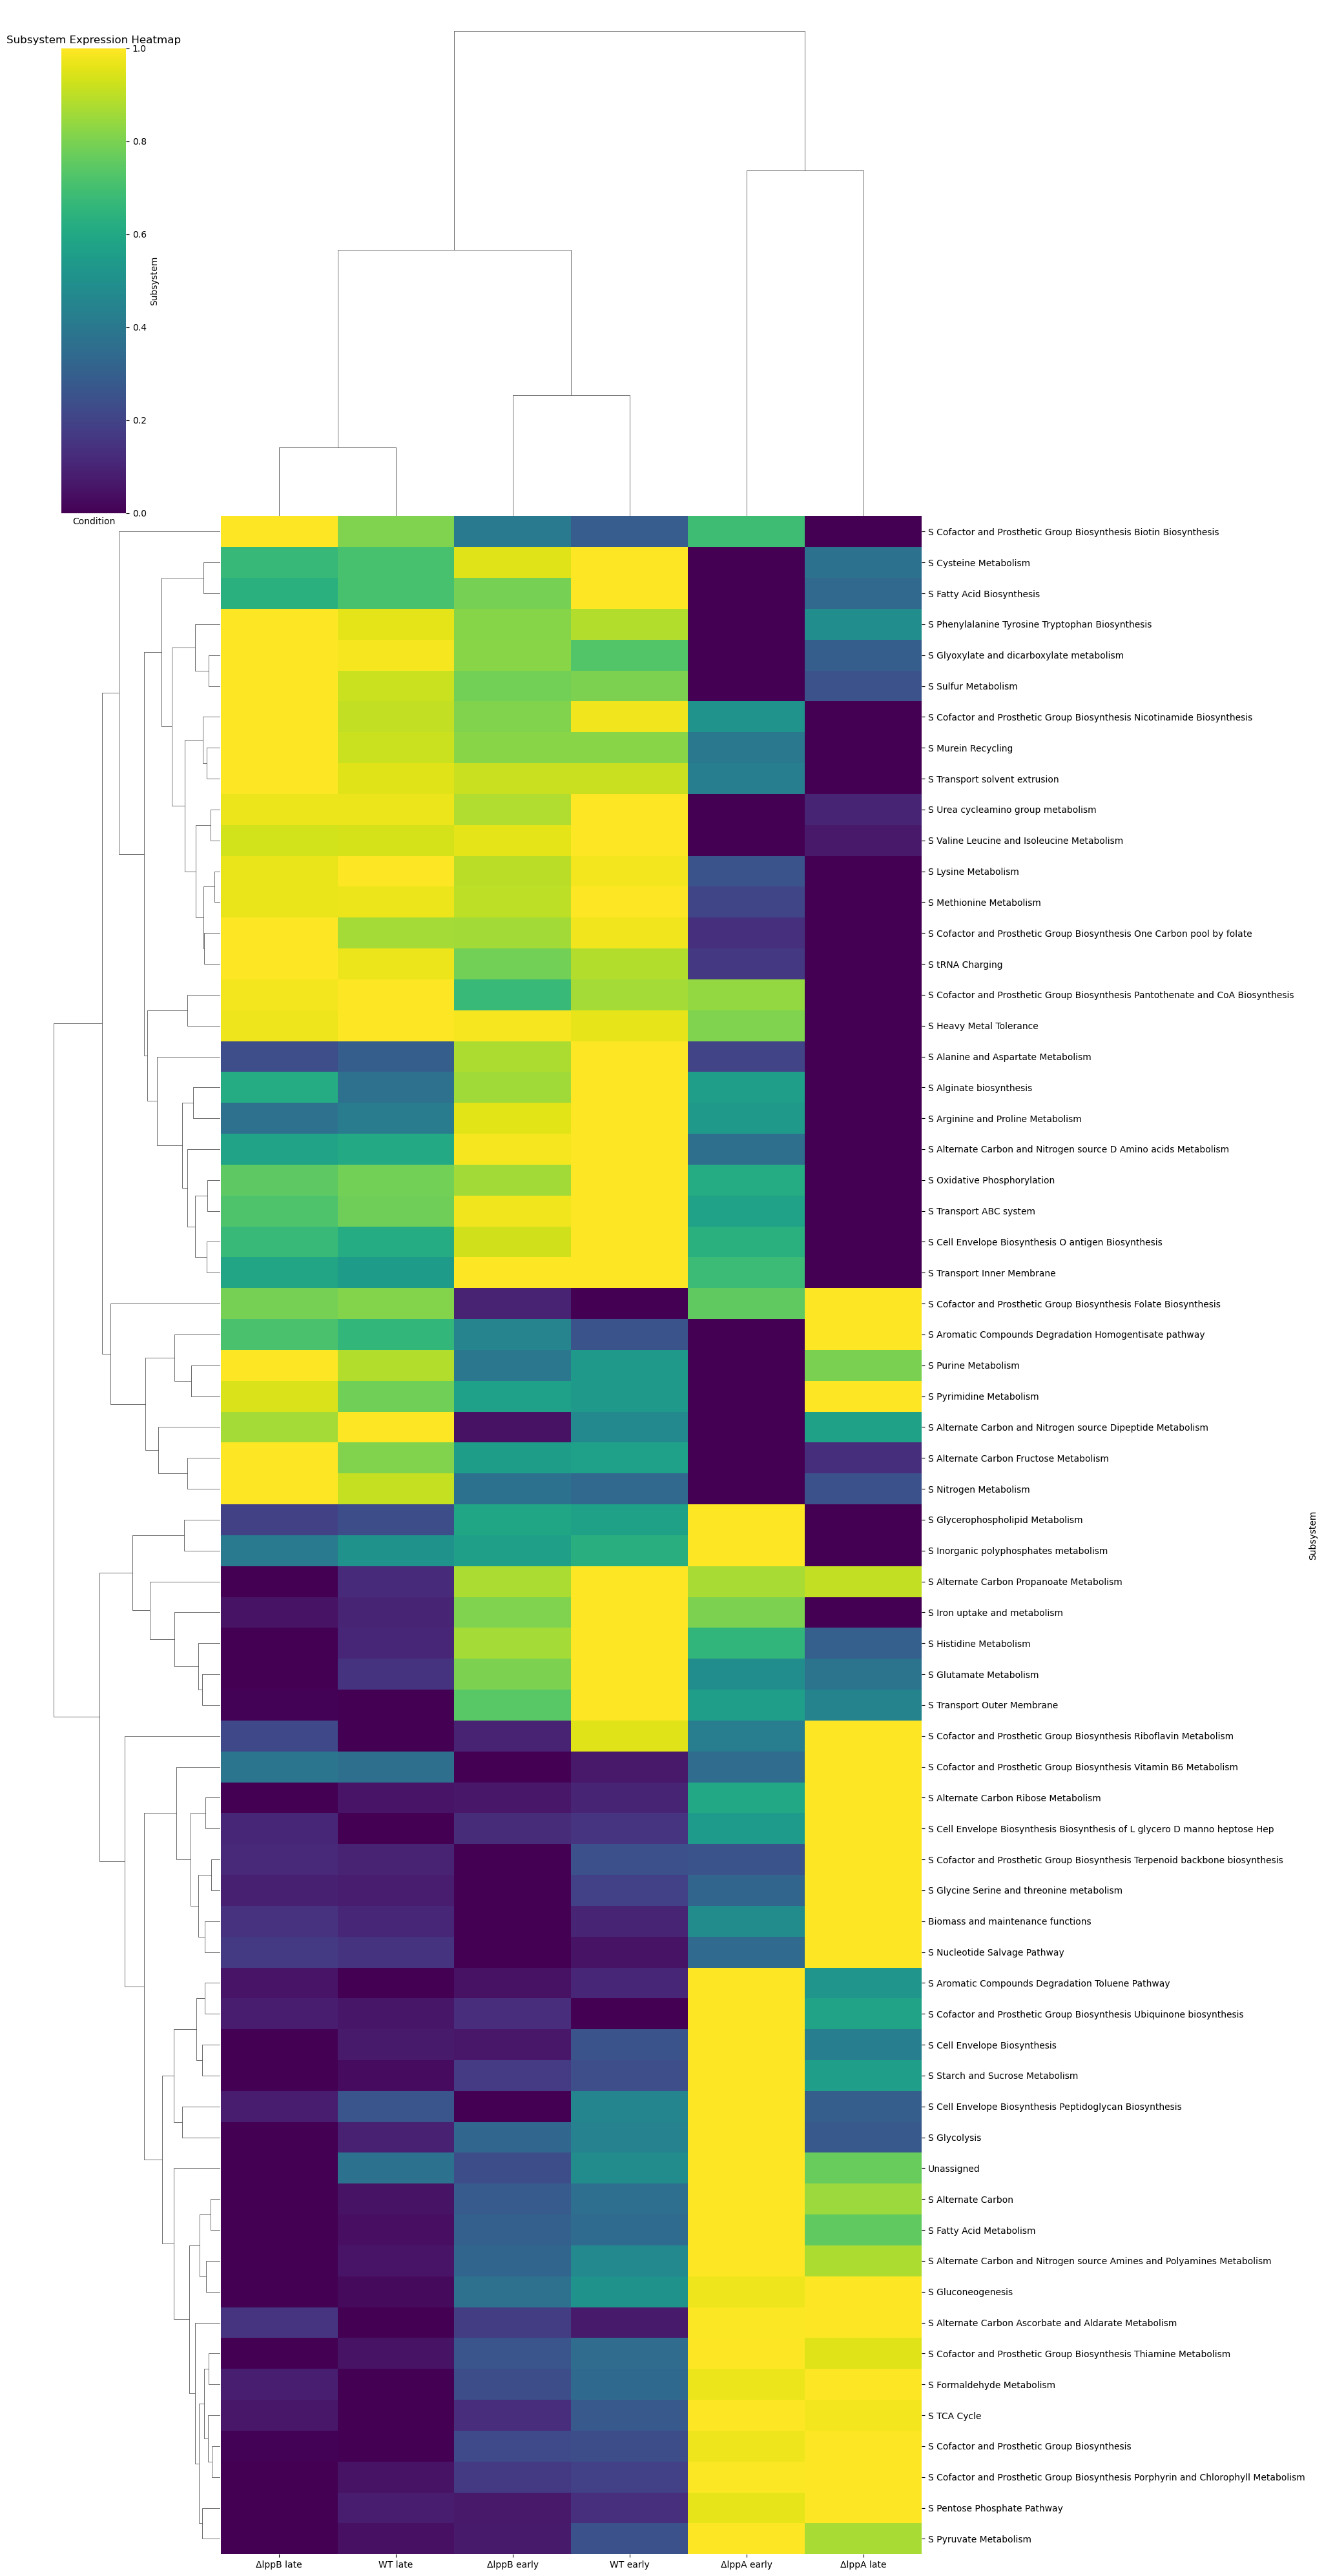

In [19]:
plot_subsystem_expression_heatmap(get_subsystem_expression_by_condition(reaction_expression_df.drop(columns=["sd"]), subsystem_mapping))

In [20]:
# Ahora vamos a hacer lo mismo pero usando los flujos de las reacciones en lugar de la expresion de las reacciones, para ver si las diferencias entre condiciones son mas evidentes a nivel de flujos que a nivel de expresion. Para ello, vamos a crear una funcion que calcule los flujos de las reacciones para cada condicion utilizando el modelo contextualizado con GIMME para cada condicion, y luego hacer el mismo proceso de agrupacion por subsistemas y plotear el heatmap con los flujos de los subsistemas para cada condicion.
# Funcion para calcular los flujos de las reacciones para cada condicion utilizando el modelo contextualizado con GIMME para cada condicion, y luego hacer el mismo proceso de agrupacion por subsistemas y plotear el heatmap con los flujos de los subsistemas para cada condicion.
def plot_subsystem_flux_heatmap(models_dict, subsystem_mapping):
    # Creamos un dataframe para almacenar los flujos de las reacciones para cada condicion
    reaction_flux_df = pd.DataFrame()
    for condition_name, model in models_dict.items():
        # Calculamos los flujos de las reacciones para la condicion actual utilizando el modelo contextualizado con GIMME para esa condicion
        solution = model.optimize()
        fluxes = solution.fluxes
        reaction_flux_df[condition_name] = fluxes

    # Añadimos una nueva columna al dataframe de flujos de reacciones con el subsistema de cada reaccion, utilizando el diccionario de mapeo entre reacciones y subsistemas
    reaction_flux_df["Subsystem"] = reaction_flux_df.index.map(subsystem_mapping)
    # Agrupamos el dataframe por subsistema y calculamos la media de flujo de las reacciones que pertenecen a cada subsistema para cada condicion, devolviendo un nuevo dataframe con el subsistema como indice y las condiciones como columnas.
    subsystem_flux_df = reaction_flux_df.groupby("Subsystem").mean()
    # Filtramos los subsistemas que tienen un flujo mayor a 0 en al menos una condicion
    filtered_subsystems = subsystem_flux_df[(subsystem_flux_df > 0).any(axis=1)]
    # Normalizamos los valores por subsistema para mostrar colores escalados para cada subsistema, es decir, que el color de cada subsistema se escale entre el valor minimo y maximo de flujo de ese subsistema en todas las condiciones, para facilitar la comparacion entre condiciones para cada subsistema.
    
    filtered_subsystems_normalized = filtered_subsystems.apply(lambda x: (x - x.min()) / (x.max() - x.min()), axis=1)
    # Para aqellos valores qe son nan o infinitos, los reemplazamos por 0 para evitar problemas al plotear el heatmap
    filtered_subsystems_normalized = filtered_subsystems_normalized.replace([np.inf, -np.inf], np.nan).fillna(0)
    # Mostramos el heatmap con seaborn
    sns.clustermap(filtered_subsystems_normalized, cmap="viridis", figsize=(20, 20))
    plt.title("Subsystem Flux Heatmap")
    plt.xlabel("Condition")
    plt.ylabel("Subsystem")
    plt.show()

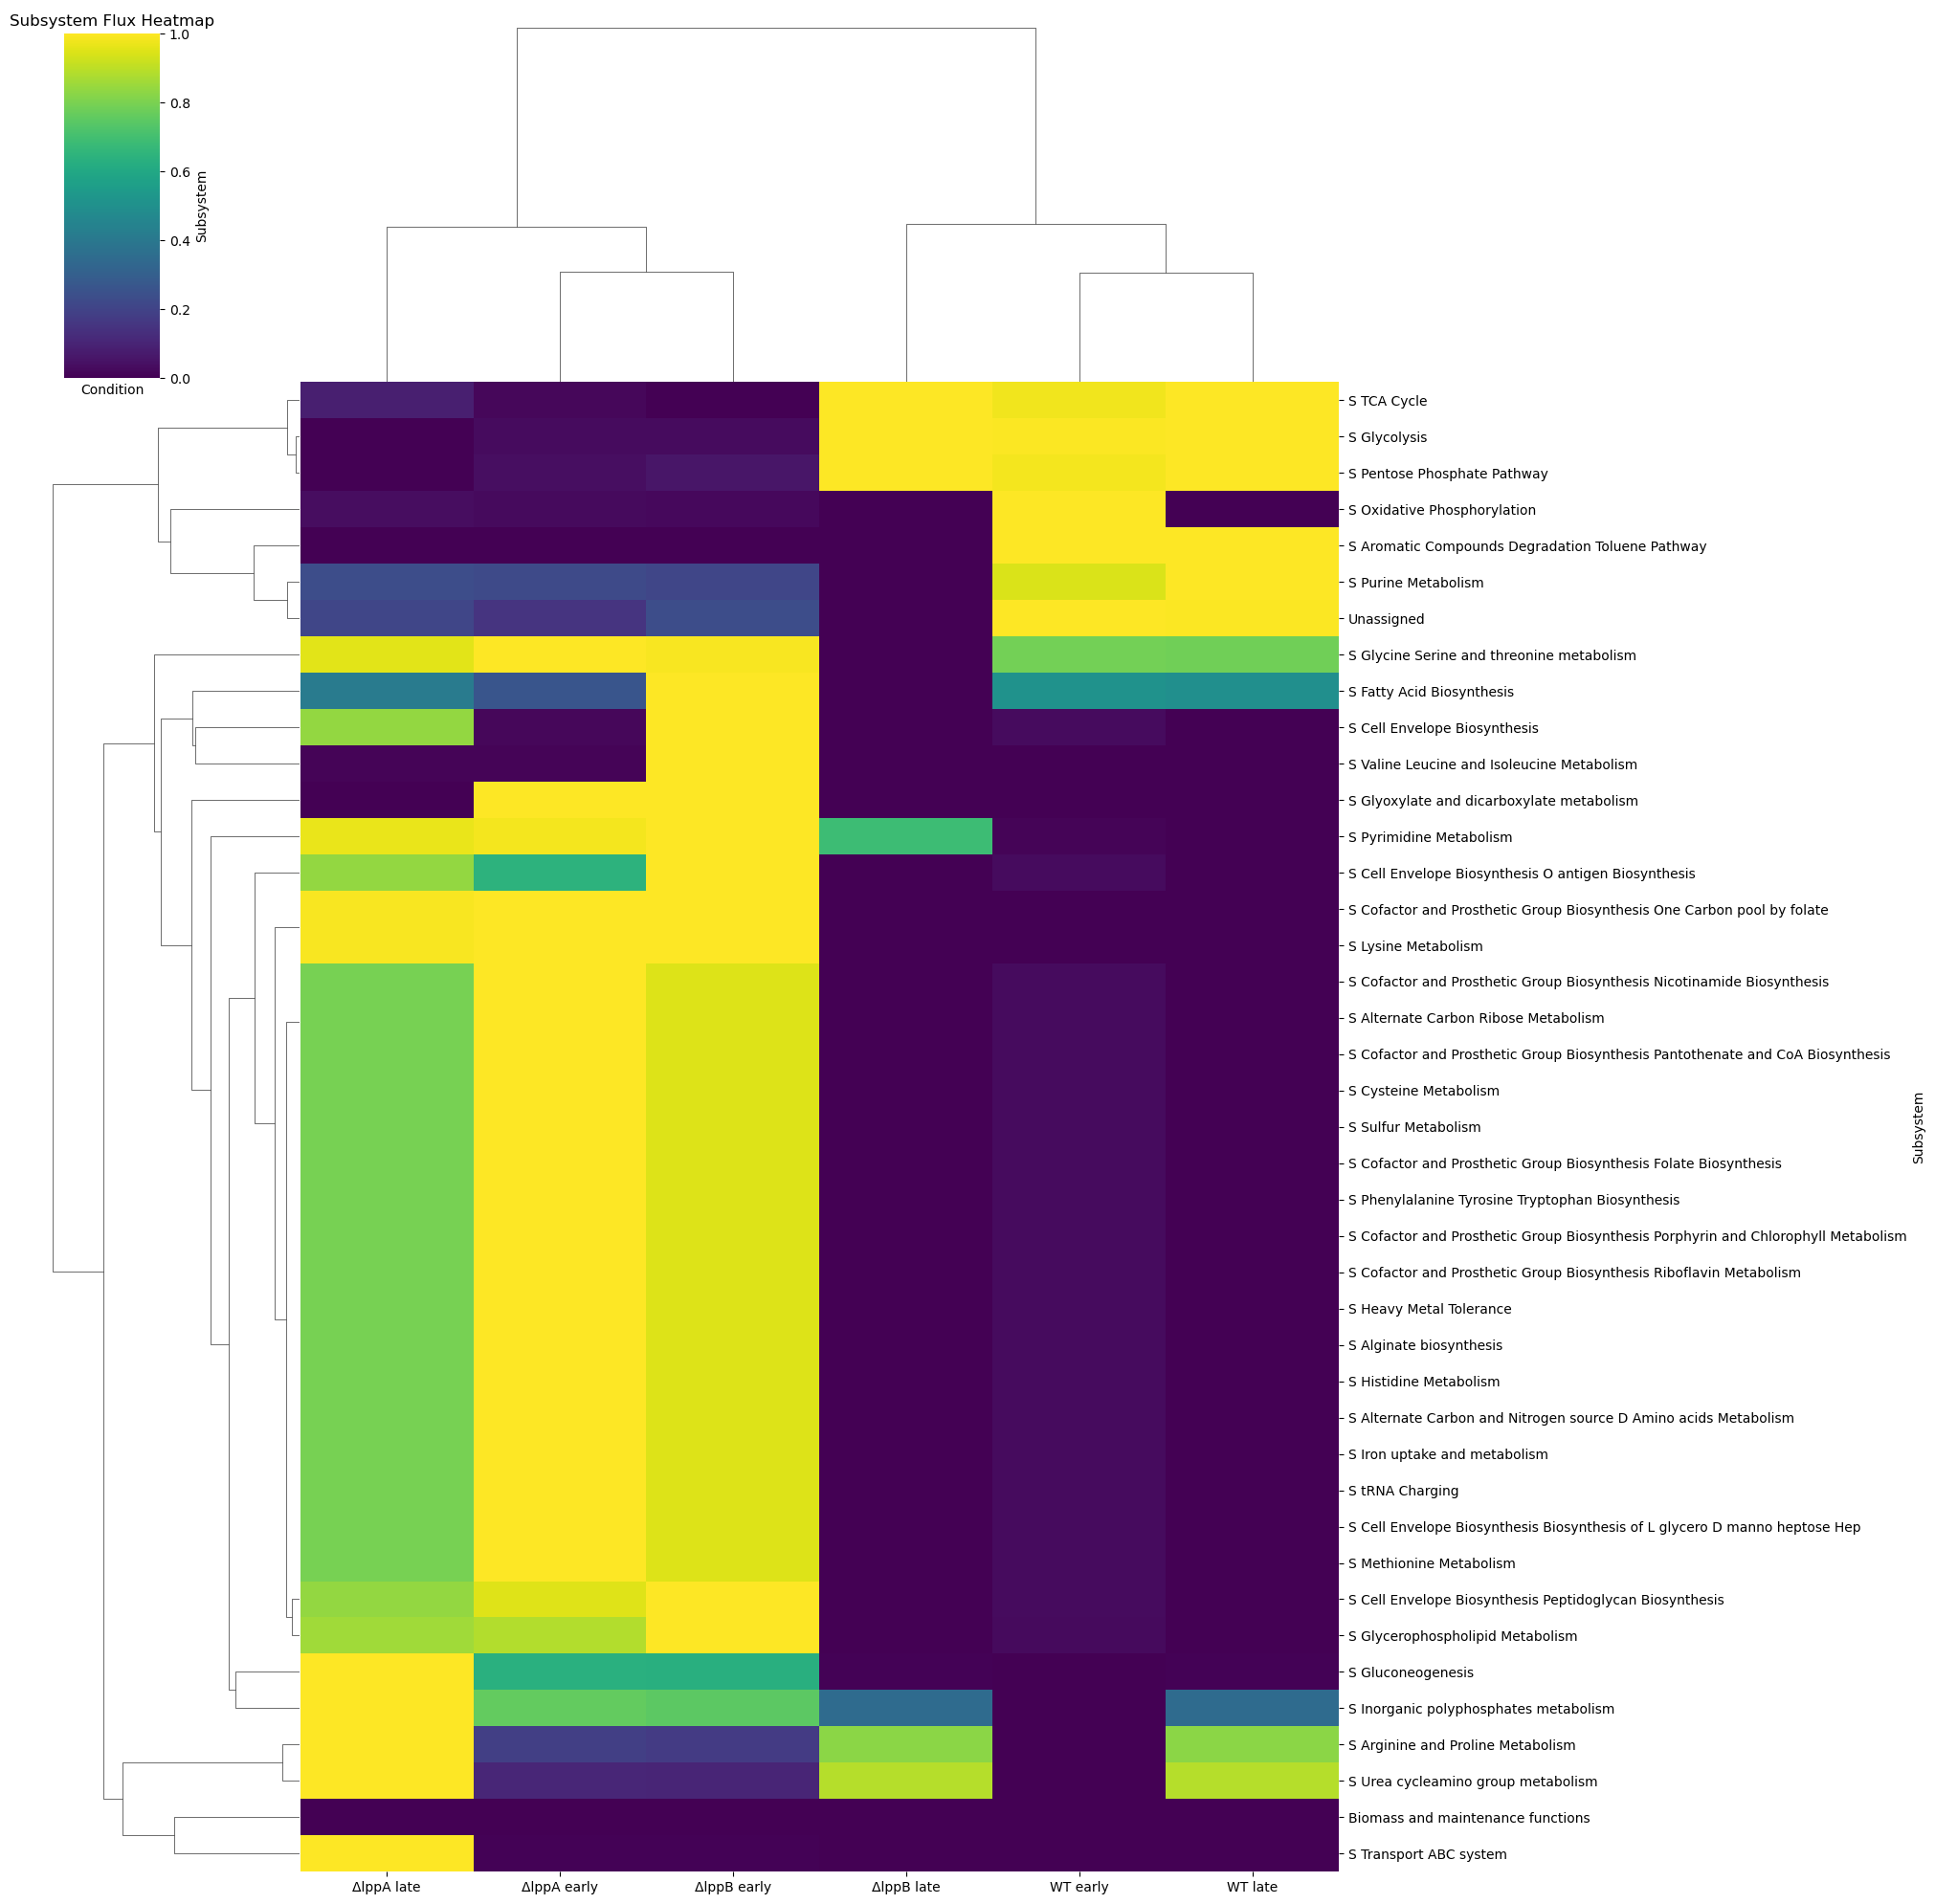

In [21]:
plot_subsystem_flux_heatmap(salmonella_models, subsystem_mapping)